**Clustering**

**Step 1: optimal number of clusters**

In [5]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt


In [7]:
rfm = pd.read_csv('olist_augmented_data/customer_rfm_augmented.csv')
print(f"RFM data loaded: {rfm.shape}")
print("\nRFM Sample:")
print(rfm.head())

rfm['monetary_log'] = np.log1p(rfm['monetary'])

features_for_clustering = ['recency', 'frequency', 'monetary_log']
X = rfm[features_for_clustering]
print(f"\nFeatures selected: {features_for_clustering}")
print(f"Data shape: {X.shape}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features standardized (scaled)")

RFM data loaded: (99433, 4)

RFM Sample:
                        customer_id  recency  frequency  monetary
0  00012a2ce6f8dcda20d059ce98491703      338          1    114.74
1  000161a058600d5901f007fab4c27140      276          3   1086.74
2  0001fd6190edaaf884bcaf3d49edf079      597          1    195.42
3  0002414f95344307404f0ace7a26f1d5      428          1    179.35
4  000379cdec625522490c315e70c7a9fb      199          1    107.01

Features selected: ['recency', 'frequency', 'monetary_log']
Data shape: (99433, 3)
Features standardized (scaled)


In [8]:
print("Calculating Elbow Method & Silhouette Scores")
K_range = range(2, 6)  
inertias = []
silhouette_scores = []

print("\nTesting different values of k...")
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    sil_score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(sil_score)
    print(f"k={k}: Inertia={kmeans.inertia_:.2f}, Silhouette Score={sil_score:.4f}")

Calculating Elbow Method & Silhouette Scores

Testing different values of k...
k=2: Inertia=133890.77, Silhouette Score=0.5201
k=3: Inertia=85563.65, Silhouette Score=0.4422
k=4: Inertia=66966.70, Silhouette Score=0.4394
k=5: Inertia=54808.35, Silhouette Score=0.3970


Visualization saved as: optimal_clusters.png


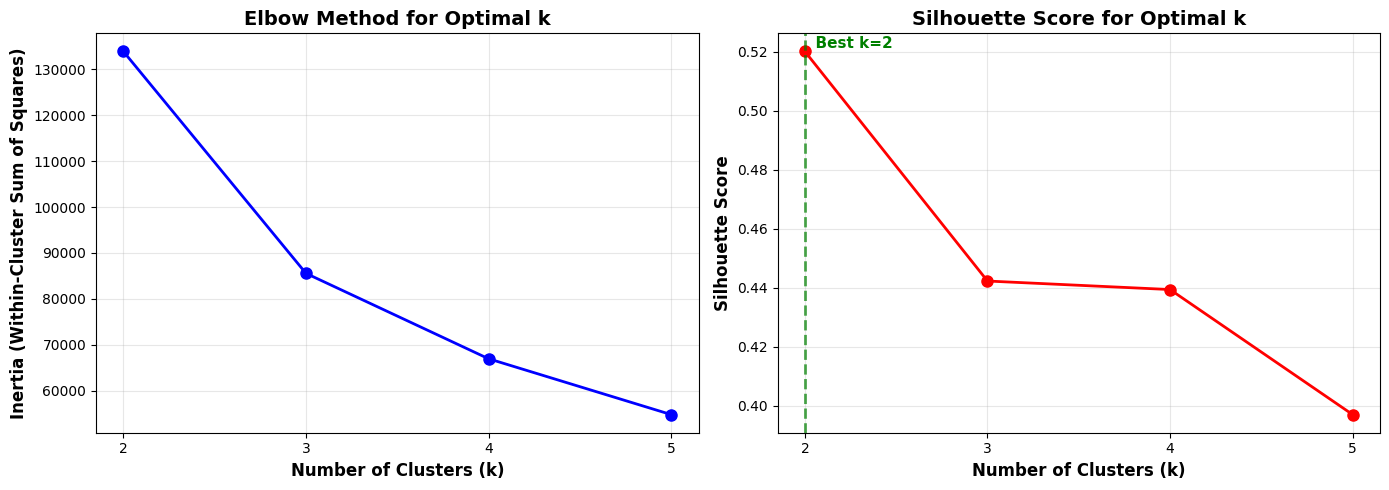

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12, fontweight='bold')
axes[0].set_title('Elbow Method for Optimal k', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(K_range)

axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Silhouette Score', fontsize=12, fontweight='bold')
axes[1].set_title('Silhouette Score for Optimal k', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(K_range)

best_k = K_range[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)
axes[1].axvline(x=best_k, color='green', linestyle='--', linewidth=2, alpha=0.7)
axes[1].text(best_k, best_score, f'  Best k={best_k}', fontsize=11, 
             color='green', fontweight='bold', va='bottom')

plt.tight_layout()
plt.savefig('results/optimal_clusters.png', dpi=300, bbox_inches='tight')
print("Visualization saved as: optimal_clusters.png")
plt.show()

In [10]:
optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"\n Optimal number of clusters based on Silhouette Score: {optimal_k}")
print(f"  Silhouette Score: {max(silhouette_scores):.4f}")

inertia_diffs = np.diff(inertias)
inertia_diffs_2 = np.diff(inertia_diffs)
elbow_index = np.argmax(inertia_diffs_2) + 1  
elbow_k = list(K_range)[elbow_index]
print(f"\n Elbow point suggests: k={elbow_k}")

metrics_df = pd.DataFrame({
    'k': list(K_range),
    'inertia': inertias,
    'silhouette_score': silhouette_scores
})
metrics_df.to_csv('olist/cluster_metrics.csv', index=False)
print("Metrics saved to: cluster_metrics.csv")



 Optimal number of clusters based on Silhouette Score: 2
  Silhouette Score: 0.5201

 Elbow point suggests: k=3
Metrics saved to: cluster_metrics.csv


**Step2: clustering**

In [11]:
n_clusters = 3

print(f"Running K-Means with {n_clusters} clusters...")
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
rfm['cluster'] = kmeans.fit_predict(X_scaled)

print(f"\n K-Means clustering completed with {n_clusters} clusters")
print("\nCluster distribution:")
print(rfm['cluster'].value_counts().sort_index())

Running K-Means with 3 clusters...

 K-Means clustering completed with 3 clusters

Cluster distribution:
cluster
0    29587
1    29871
2    39975
Name: count, dtype: int64


In [12]:
output_path = 'olist_processed_data\customer_rfm_clustered.csv'
rfm.to_csv(output_path, index=False)
print(f" Saved clustered data to: {output_path}")

print(f"\nTotal Customers: {len(rfm)}")
print(f"Number of Clusters: {n_clusters}")

print("\nSample of clustered data:")
print(rfm[['customer_id', 'recency', 'frequency', 'monetary', 'cluster']].head(10))

 Saved clustered data to: olist_processed_data\customer_rfm_clustered.csv

Total Customers: 99433
Number of Clusters: 3

Sample of clustered data:
                        customer_id  recency  frequency  monetary  cluster
0  00012a2ce6f8dcda20d059ce98491703      338          1    114.74        0
1  000161a058600d5901f007fab4c27140      276          3   1086.74        1
2  0001fd6190edaaf884bcaf3d49edf079      597          1    195.42        0
3  0002414f95344307404f0ace7a26f1d5      428          1    179.35        0
4  000379cdec625522490c315e70c7a9fb      199          1    107.01        2
5  0004164d20a9e969af783496f3408652       17          3   1822.70        1
6  000419c5494106c306a97b5635748086       18          3   1520.26        1
7  00046a560d407e99b969756e0b10f282      212          2    854.67        1
8  00050bf6e01e69d5c0fd612f1bcfb69c      396          1     85.23        0
9  000598caf2ef4117407665ac33275130       68          1   1255.71        1


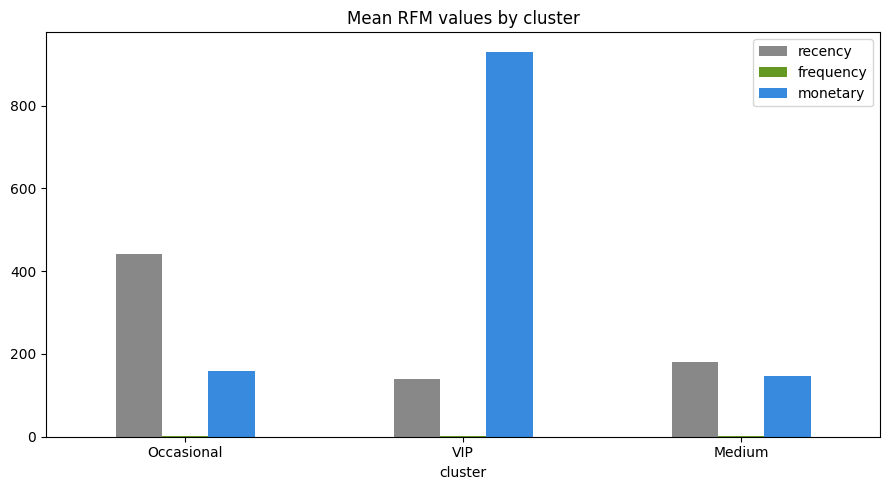

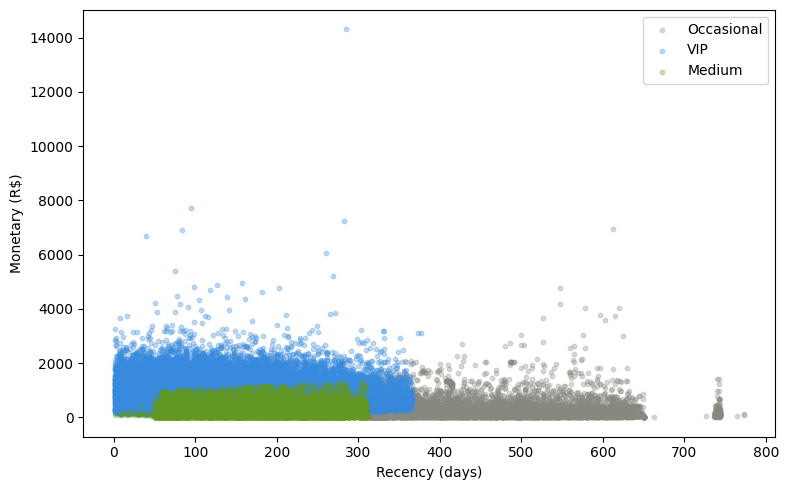

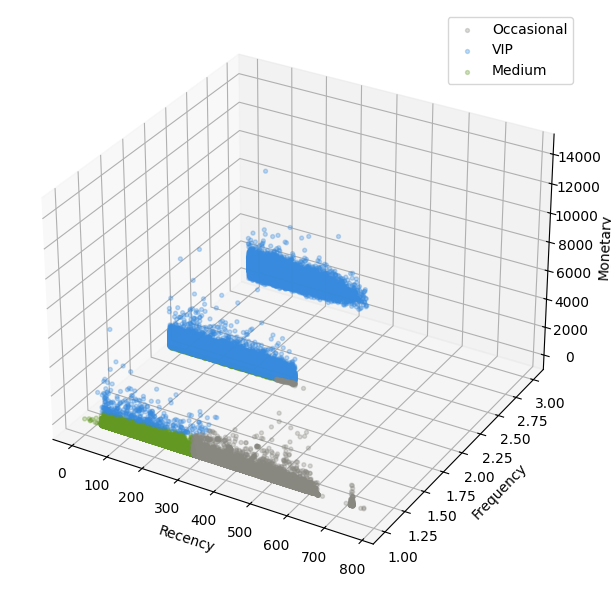

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

rfm = pd.read_csv('olist_processed_data\customer_rfm_clustered.csv')

cluster_map = {1: 'VIP', 2: 'Medium', 0: 'Occasional'}
color_map   = {1: '#378ADD', 2: '#639922', 0: '#888780'}
rfm['segment'] = rfm['cluster'].map(cluster_map)

summary = rfm.groupby('cluster')[['recency','frequency','monetary']].mean().round(2)
summary.index = summary.index.map(cluster_map)
summary.plot(kind='bar', figsize=(9, 5), color=['#888', '#639922', '#378ADD'])
plt.title('Mean RFM values by cluster')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
for c, grp in rfm.groupby('cluster'):
    ax.scatter(grp['recency'], grp['monetary'],
               label=cluster_map[c], color=color_map[c], alpha=0.3, s=10)
ax.set_xlabel('Recency (days)')
ax.set_ylabel('Monetary (R$)')
ax.legend()
plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')
for c, grp in rfm.groupby('cluster'):
    ax.scatter(grp['recency'], grp['frequency'], grp['monetary'],
               label=cluster_map[c], color=color_map[c], alpha=0.3, s=8)
ax.set_xlabel('Recency'); ax.set_ylabel('Frequency'); ax.set_zlabel('Monetary')
ax.legend()
plt.tight_layout()
plt.show()